In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.core.common import random_state

%matplotlib inline

In [45]:
df = pd.read_csv('../data/bikes_rent.csv')
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [46]:
df.shape

(731, 13)

In [47]:
df.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,20.310776,23.717699,62.789406,12.762576,5.705220,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,7.505091,8.148059,14.242910,5.192357,2.321125,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,0.670650,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.820424,16.892125,52.000000,9.041650,4.041864,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,20.431653,24.336650,62.666700,12.125325,5.420351,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.872076,30.430100,73.020850,15.625371,6.984967,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,15.198937,8714.000000


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          731 non-null    int64  
 1   yr              731 non-null    int64  
 2   mnth            731 non-null    int64  
 3   holiday         731 non-null    int64  
 4   weekday         731 non-null    int64  
 5   workingday      731 non-null    int64  
 6   weathersit      731 non-null    int64  
 7   temp            731 non-null    float64
 8   atemp           731 non-null    float64
 9   hum             731 non-null    float64
 10  windspeed(mph)  731 non-null    float64
 11  windspeed(ms)   731 non-null    float64
 12  cnt             731 non-null    int64  
dtypes: float64(5), int64(8)
memory usage: 74.4 KB


In [49]:
plt.rcParams['figure.figsize'] = (12, 8)

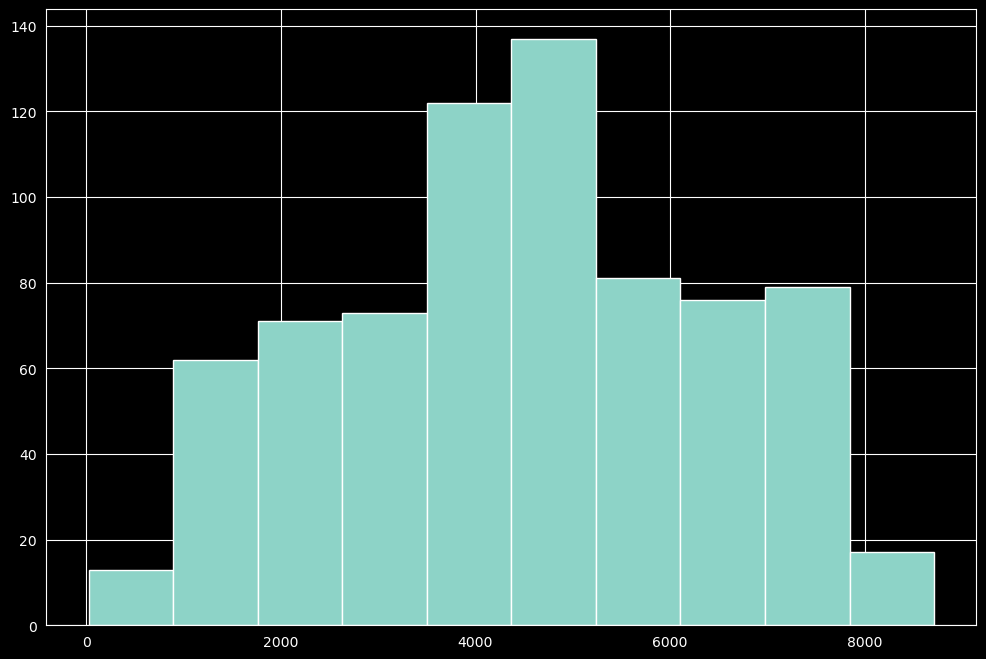

In [50]:
df['cnt'].hist();

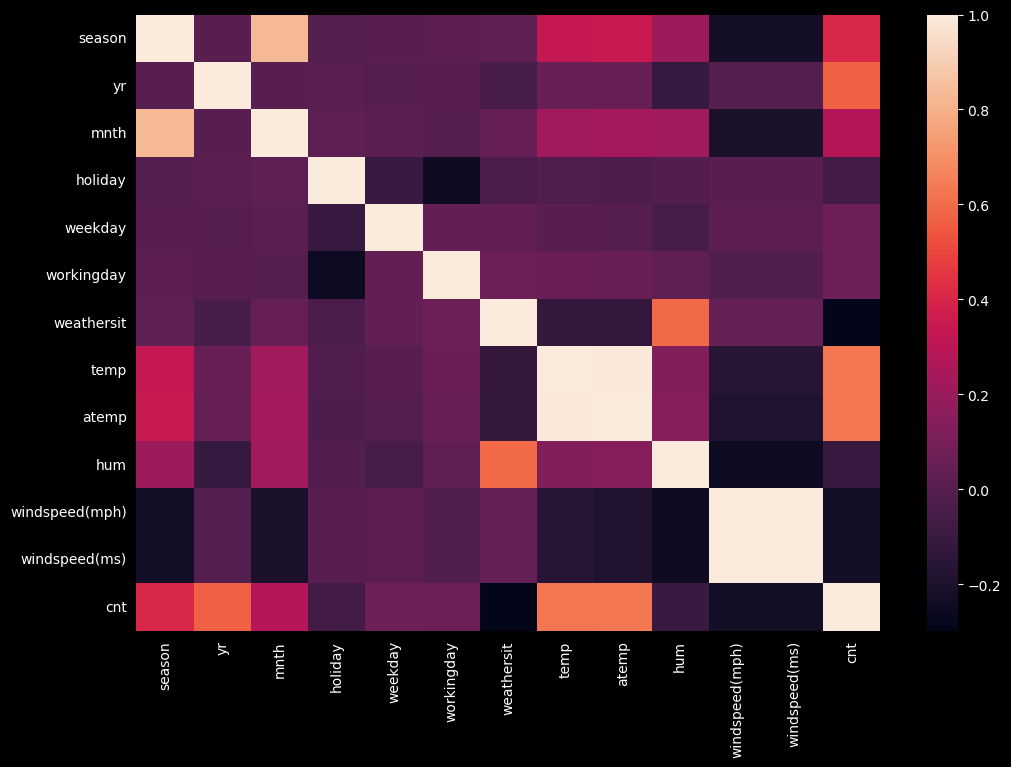

In [51]:
sns.heatmap(df.corr());

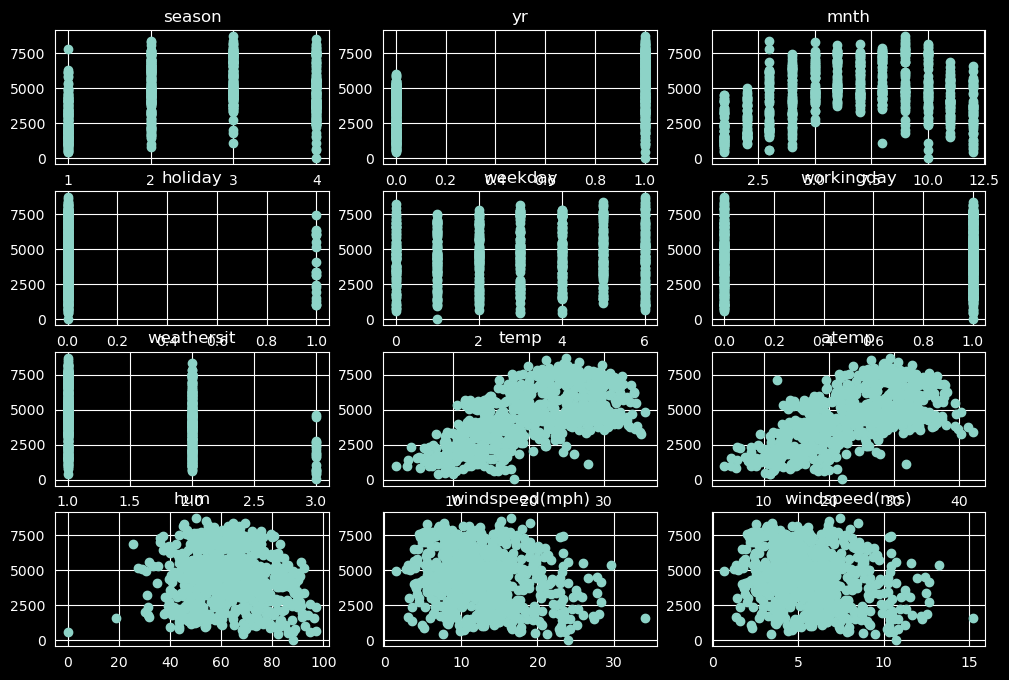

In [52]:
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(4, 3, i + 1)
    plt.scatter(df[col], df['cnt'])
    plt.title(col)

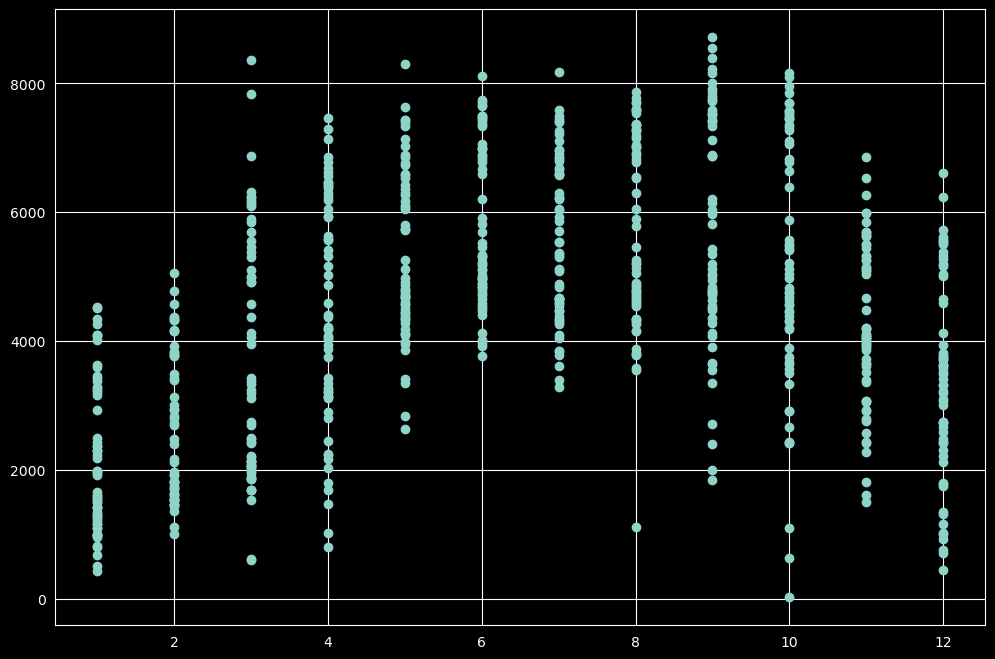

In [53]:
plt.scatter(df.mnth, df.cnt);

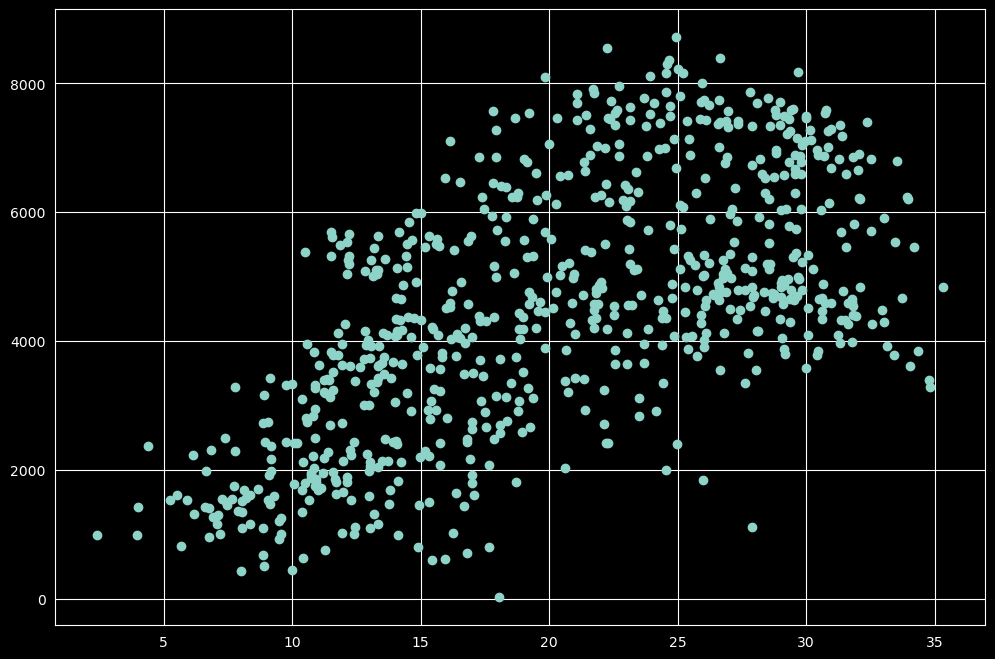

In [54]:
plt.scatter(df.temp, df.cnt);

In [55]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [56]:
linreg = LinearRegression()
lasso = Lasso(random_state=17)
ridge = Ridge(random_state=17)
lasso_cv = LassoCV(random_state=17)
ridge_cv = RidgeCV()

In [57]:
X, y = df.drop('cnt', axis=1).values, df['cnt'].values

In [58]:
train_part_size = int(.7 * X.shape[0])

X_train, X_valid = X[:train_part_size, :], X[train_part_size:, :]
y_train, y_valid = y[:train_part_size], y[train_part_size:]

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [60]:
linreg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
np.sqrt(mean_squared_error(y_valid, linreg.predict(X_valid_scaled)))

np.float64(1121.795208027491)

In [62]:
pd.DataFrame(linreg.coef_, df.columns[:-1], columns=['coef']).sort_values(by='coef', ascending=False)

,coef
windspeed(ms),3.049612e+12
yr,9.540703e+02
atemp,8.911653e+02
season,4.048576e+02
weekday,1.037112e+02
temp,6.249171e+01
mnth,3.081012e+01
workingday,1.470207e+01
holiday,-6.757357e+01
hum,-1.589776e+02


In [63]:
def train_validate_report(model, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names):
    model.fit(X_train_scaled, y_train)
    print(np.sqrt(mean_squared_error(y_valid, model.predict(X_valid_scaled))))

    print(pd.DataFrame(model.coef_, feature_names, columns=['coef']).sort_values(by='coef', ascending=False))

In [64]:
train_validate_report(lasso, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names=df.columns[:-1])

1120.7214094932299
                      coef
yr              952.804560
atemp           877.159813
season          403.416439
weekday         102.643044
temp             75.953962
mnth             29.857599
workingday       14.173377
windspeed(ms)    -0.000000
holiday         -67.073435
hum            -157.547615
windspeed(mph) -187.341353
weathersit     -293.177257


In [65]:
train_validate_report(lasso_cv, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names=df.columns[:-1])

1120.7436606195304
                      coef
yr              951.135002
atemp           883.344030
season          403.009581
weekday         101.892690
temp             69.238981
mnth             28.608639
workingday       13.478682
windspeed(ms)    -0.000000
holiday         -66.360460
hum            -156.248289
windspeed(mph) -186.267734
weathersit     -293.016582


In [66]:
train_validate_report(ridge, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names=df.columns[:-1])

1119.5605202108381
                      coef
yr              954.075878
atemp           730.747340
season          400.114172
temp            221.406072
weekday         103.198680
mnth             34.687740
workingday       15.334339
holiday         -69.046689
windspeed(ms)   -95.819798
windspeed(mph)  -95.819798
hum            -157.702520
weathersit     -293.899386


In [67]:
train_validate_report(ridge_cv, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names=df.columns[:-1])

1118.9035433219817
                      coef
yr              934.401985
atemp           534.482125
temp            410.485392
season          375.585733
weekday         100.838401
mnth             48.142392
workingday       16.165284
holiday         -70.019251
windspeed(ms)   -97.770430
windspeed(mph)  -97.770430
hum            -155.174377
weathersit     -291.035853


In [68]:
def train_validate_report(model, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names):
    model.fit(X_train_scaled, y_train)
    print(np.sqrt(mean_squared_error(y_valid, model.predict(X_valid_scaled))))

    importance = model.feature_importances_
    print(pd.DataFrame(importance, feature_names, columns=['coef']).sort_values(by='coef', ascending=False))

In [69]:
random_forest = RandomForestRegressor(random_state=17, n_estimators=500)

In [70]:
train_validate_report(random_forest, X_train_scaled, y_train, X_valid_scaled, y_valid, feature_names=df.columns[:-1])

1047.1376755069205
                    coef
temp            0.298609
atemp           0.243309
yr              0.199314
hum             0.070565
season          0.062295
weathersit      0.030535
mnth            0.027786
windspeed(mph)  0.020349
weekday         0.019819
windspeed(ms)   0.019613
workingday      0.005191
holiday         0.002615
